# 📊 Estatística Descritiva — MJ Dataset

> **Etapa 2 do portfólio.** Com os dados já *tidy* (ver `01_data_wrangling`),
> agora descrevemos o catálogo de Michael Jackson com medidas de **tendência
> central**, **dispersão** e **forma**, e investigamos a pergunta clássica:
> ***Thriller é estatisticamente um outlier?***

**Convenção:** código e nomes de colunas em inglês; narrativa em português.

**Roteiro**
1. Visão geral dos dados
2. Medidas de tendência central
3. Medidas de dispersão
4. Forma da distribuição (assimetria e curtose)
5. Visualizações (histogramas e boxplots)
6. *Thriller* é outlier? (IQR + z-score)
7. Perguntas descritivas do README

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy import stats

# Caminhos
ROOT = Path.cwd().parents[1] if (Path.cwd().name == "python") else Path.cwd()
PROC = ROOT / "data" / "processed"
FIG = ROOT / "analysis" / "python" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

# Estilo visual consistente
plt.rcParams.update({
    "figure.figsize": (9, 5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11,
})
MJ_GOLD = "#C9A227"

singles = pd.read_csv(PROC / "mj_singles.csv")
albums = pd.read_csv(PROC / "mj_albums.csv")
print(f"Singles: {singles.shape[0]} linhas | Álbuns: {albums.shape[0]} linhas")

Singles: 27 linhas | Álbuns: 6 linhas


## 1. Visão geral dos dados

Antes de qualquer estatística, olhamos o **grão** e os **tipos** das variáveis.
Lembrete do wrangling: vendas/Grammys são do **álbum** (tabela `albums`), não do
single — por isso análises de vendas usam `albums` (6 obs.), e não os 27 singles.

In [2]:
singles.info()
singles.head()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   single_id              27 non-null     int64  
 1   album_id               27 non-null     int64  
 2   album                  27 non-null     str    
 3   album_year             27 non-null     int64  
 4   single                 27 non-null     str    
 5   single_year            27 non-null     int64  
 6   decade                 27 non-null     int64  
 7   genre                  27 non-null     str    
 8   genre_primary          27 non-null     str    
 9   duration_min           27 non-null     float64
 10  peak_us                26 non-null     float64
 11  peak_uk                25 non-null     float64
 12  weeks_chart_us         26 non-null     float64
 13  reached_no1_us         26 non-null     object 
 14  has_video              27 non-null     bool   
 15  award              

,single_id,album_id,album,album_year,single,single_year,decade,genre,genre_primary,duration_min,peak_us,peak_uk,weeks_chart_us,reached_no1_us,has_video,award,tracks,album_sales_mi,album_grammys,album_weeks_no1_bb200
0,1,1,Off the Wall,1979,Don't Stop 'Til You Get Enough,1979,1970,Disco/Soul,Disco,3.62,1.0,3.0,24.0,True,True,Grammy Melhor R&B,10,20,1,1
1,2,1,Off the Wall,1979,Rock with You,1980,1980,Disco/Soul,Disco,3.65,1.0,7.0,24.0,True,True,NaN,10,20,1,1
2,3,1,Off the Wall,1979,She's Out of My Life,1980,1980,Soft Rock/Pop,Soft Rock,3.35,10.0,3.0,18.0,False,True,NaN,10,20,1,1
3,4,2,Thriller,1982,The Girl Is Mine,1982,1980,Pop/R&B,Pop,3.42,2.0,8.0,21.0,False,True,NaN,9,70,8,37
4,5,2,Thriller,1982,Beat It,1983,1980,Hard Rock/Pop,Hard Rock,4.18,1.0,3.0,22.0,True,True,MTV VMA,9,70,8,37


In [3]:
# Variáveis quantitativas que vamos descrever
num_singles = ["duration_min", "peak_us", "peak_uk", "weeks_chart_us"]
singles[num_singles].describe().round(2)

,duration_min,peak_us,peak_uk,weeks_chart_us
count,27.00,26.00,25.00,26.00
mean,4.53,6.92,5.68,16.65
std,0.84,8.62,5.96,4.23
min,3.35,1.00,1.00,8.00
25%,4.01,1.00,2.00,14.00
50%,4.32,3.50,3.00,16.00
75%,4.97,9.25,8.00,18.00
max,6.45,30.00,25.00,25.00


## 2. Medidas de tendência central

- **Média**: sensível a valores extremos.
- **Mediana**: robusta a outliers (o "valor do meio").
- **Moda**: valor mais frequente.

A comparação **média × mediana** já antecipa assimetria.

In [4]:
def central_tendency(s: pd.Series) -> dict:
    s = s.dropna()
    mode = s.mode()
    return {
        "n": int(s.size),
        "mean": round(s.mean(), 2),
        "median": round(s.median(), 2),
        "mode": mode.iloc[0] if not mode.empty else np.nan,
    }

rows = {c: central_tendency(singles[c]) for c in num_singles}
rows["album_sales_mi"] = central_tendency(albums["album_sales_mi"])
ct = pd.DataFrame(rows).T
ct

,n,mean,median,mode
duration_min,27.0,4.53,4.32,4.97
peak_us,26.0,6.92,3.50,1.00
peak_uk,25.0,5.68,3.00,3.00
weeks_chart_us,26.0,16.65,16.00,16.00
album_sales_mi,6.0,32.00,27.00,13.00


**Leitura:** em `album_sales_mi`, a **média** é bem maior que a **mediana** —
sinal claro de **assimetria à direita** puxada por um valor gigante (*Thriller*).
A mediana descreve melhor o "álbum típico" do que a média neste caso.

## 3. Medidas de dispersão

Quão espalhados estão os dados em torno do centro?

- **Amplitude** (range) = máx − mín
- **Variância / Desvio padrão** (DP)
- **IQR** (intervalo interquartílico) = Q3 − Q1 — robusto a outliers
- **CV** (coeficiente de variação) = DP / média — dispersão **relativa**, comparável entre variáveis de escalas diferentes

In [5]:
def dispersion(s: pd.Series) -> dict:
    s = s.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    return {
        "range": round(s.max() - s.min(), 2),
        "std": round(s.std(ddof=1), 2),
        "IQR": round(q3 - q1, 2),
        "CV_%": round(100 * s.std(ddof=1) / s.mean(), 1) if s.mean() else np.nan,
    }

disp = {c: dispersion(singles[c]) for c in num_singles}
disp["album_sales_mi"] = dispersion(albums["album_sales_mi"])
pd.DataFrame(disp).T

,range,std,IQR,CV_%
duration_min,3.1,0.84,0.96,18.5
peak_us,29.0,8.62,8.25,124.5
peak_uk,24.0,5.96,6.00,105.0
weeks_chart_us,17.0,4.23,4.00,25.4
album_sales_mi,57.0,20.29,13.75,63.4


**Leitura:** `peak_us` costuma ter **CV alto** — MJ tem muitos #1 e alguns
singles bem mais abaixo, gerando grande dispersão relativa. Já `weeks_chart_us`
é mais estável (longevidade em chart varia menos).

## 4. Forma da distribuição

- **Assimetria (skewness):** >0 cauda à direita; <0 cauda à esquerda; ≈0 simétrica.
- **Curtose (kurtosis):** caudas/picos — >0 leptocúrtica (caudas pesadas).

In [6]:
shape = {}
for c in num_singles:
    s = singles[c].dropna()
    shape[c] = {"skewness": round(stats.skew(s), 2), "kurtosis": round(stats.kurtosis(s), 2)}
s = albums["album_sales_mi"].dropna()
shape["album_sales_mi"] = {"skewness": round(stats.skew(s), 2), "kurtosis": round(stats.kurtosis(s), 2)}
pd.DataFrame(shape).T

,skewness,kurtosis
duration_min,0.80,-0.19
peak_us,1.61,1.40
peak_uk,2.05,3.80
weeks_chart_us,0.18,-0.28
album_sales_mi,1.19,0.18


## 5. Visualizações

Histogramas (distribuição) e boxplots (centro, dispersão e outliers) das
variáveis-chave dos singles.

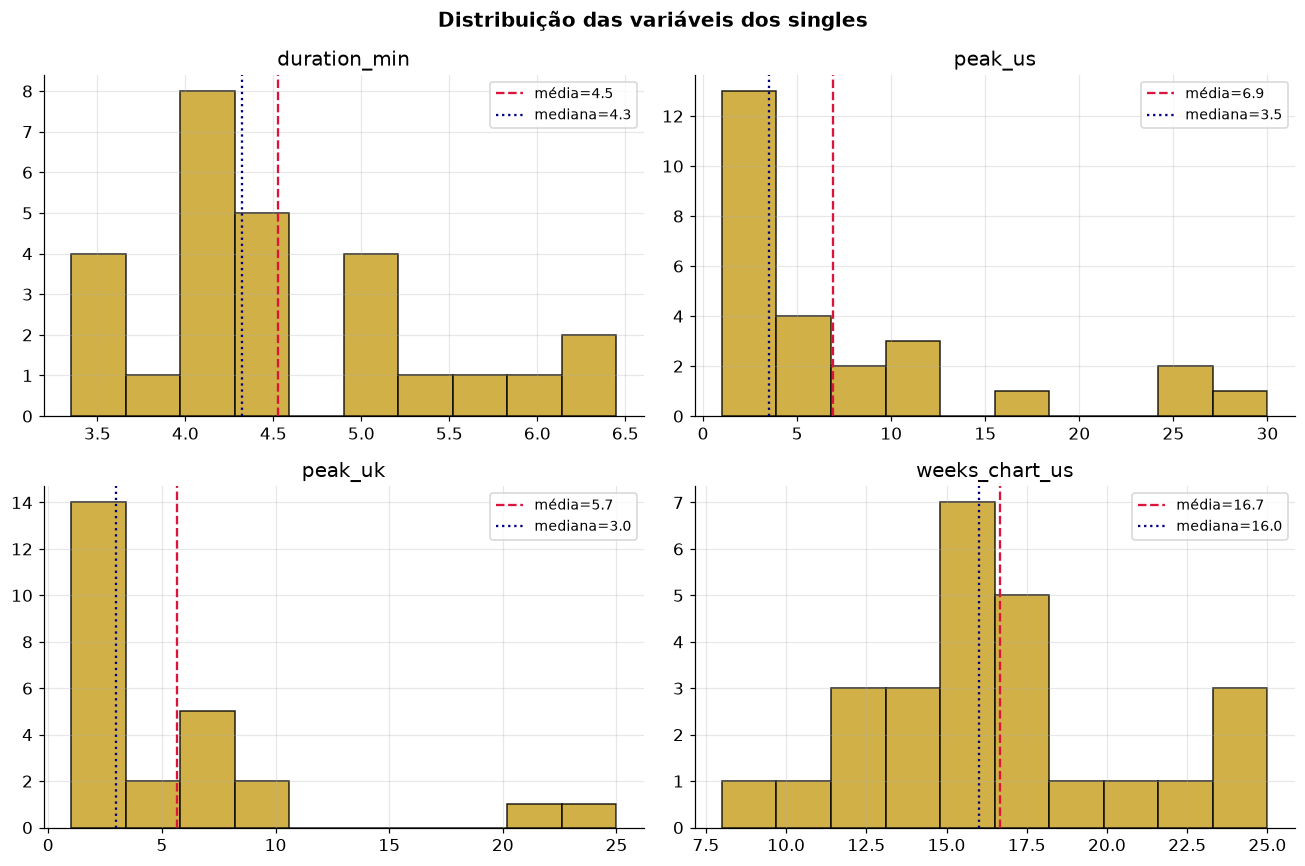

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, c in zip(axes.ravel(), num_singles):
    data = singles[c].dropna()
    ax.hist(data, bins=10, color=MJ_GOLD, edgecolor="black", alpha=0.85)
    ax.axvline(data.mean(), color="crimson", ls="--", lw=1.5, label=f"média={data.mean():.1f}")
    ax.axvline(data.median(), color="navy", ls=":", lw=1.5, label=f"mediana={data.median():.1f}")
    ax.set_title(c); ax.legend(fontsize=9)
fig.suptitle("Distribuição das variáveis dos singles", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG / "02_histograms.png", bbox_inches="tight")
plt.show()

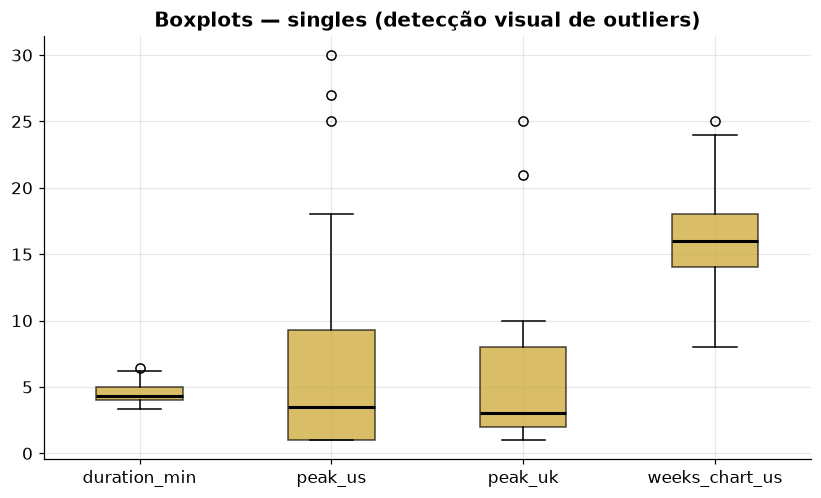

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot([singles[c].dropna() for c in num_singles], tick_labels=num_singles,
                patch_artist=True, medianprops=dict(color="black", lw=2))
for patch in bp["boxes"]:
    patch.set_facecolor(MJ_GOLD); patch.set_alpha(0.7)
ax.set_title("Boxplots — singles (detecção visual de outliers)", fontweight="bold")
fig.savefig(FIG / "02_boxplots.png", bbox_inches="tight")
plt.show()

## 6. *Thriller* é estatisticamente um outlier?

Pergunta direta do README. Testamos nas **vendas de álbum** (`albums`, 6 obs.)
com dois critérios padrão:

- **Regra do IQR (Tukey):** outlier se valor > Q3 + 1,5·IQR ou < Q1 − 1,5·IQR.
- **Z-score:** quantos desvios-padrão o valor está da média (|z| > 2 costuma ser
  considerado atípico).

⚠️ Com n=6 a estatística é frágil (amostra minúscula) — usamos isto de forma
**descritiva/ilustrativa**, não inferencial.

In [9]:
sales = albums.set_index("album")["album_sales_mi"]
q1, q3 = sales.quantile(0.25), sales.quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr
z = (sales - sales.mean()) / sales.std(ddof=1)

report = pd.DataFrame({
    "sales_mi": sales,
    "z_score": z.round(2),
    "outlier_IQR": (sales > upper) | (sales < lower),
    "outlier_z>2": z.abs() > 2,
}).sort_values("sales_mi", ascending=False)
print(f"Q1={q1}  Q3={q3}  IQR={iqr}  | limite superior IQR = {upper:.1f} mi")
report

Q1=20.5  Q3=34.25  IQR=13.75  | limite superior IQR = 54.9 mi


,sales_mi,z_score,outlier_IQR,outlier_z>2
album,,,,
Thriller,70,1.87,True,False
Bad,35,0.15,False,False
Dangerous,32,0.00,False,False
HIStory,22,-0.49,False,False
Off the Wall,20,-0.59,False,False
Invincible,13,-0.94,False,False


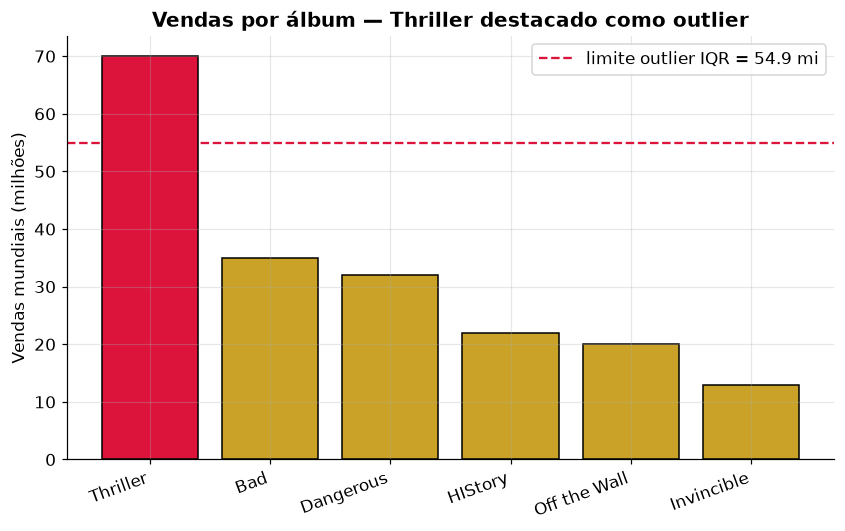

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = [MJ_GOLD if not o else "crimson" for o in report["outlier_IQR"]]
ax.bar(report.index, report["sales_mi"], color=colors, edgecolor="black")
ax.axhline(upper, color="crimson", ls="--", label=f"limite outlier IQR = {upper:.1f} mi")
ax.set_ylabel("Vendas mundiais (milhões)")
ax.set_title("Vendas por álbum — Thriller destacado como outlier", fontweight="bold")
ax.legend()
plt.xticks(rotation=20, ha="right")
fig.savefig(FIG / "02_thriller_outlier.png", bbox_inches="tight")
plt.show()

**Conclusão (6):** *Thriller* (70 mi) ultrapassa o limite superior do IQR e tem
o maior z-score — é, sim, um **outlier** no catálogo. Isso justifica reportar a
**mediana** (não a média) ao descrever vendas "típicas" de um álbum de MJ.

## 7. Perguntas descritivas do README

Respondemos aqui o que é **descritivo**. Os testes formais (significância)
ficam para os notebooks de **teste de hipótese** e **regressão**.

In [11]:
# (a) Os singles de MJ ficam mais de 15 semanas no chart?
w = singles["weeks_chart_us"].dropna()
pct = (w > 15).mean() * 100
print(f"(a) {pct:.0f}% dos singles ficaram >15 semanas no Hot 100 "
      f"(mediana = {w.median():.0f} semanas).")

# (b) Singles COM clipe ficam mais tempo no chart? (descritivo: médias por grupo)
grp = singles.groupby("has_video")["weeks_chart_us"].agg(["count", "mean", "median"]).round(2)
print("\n(b) Semanas em chart por presença de clipe:")
print(grp)

# (c) Peak EUA x semanas em chart — correlação (descritiva)
sub = singles.dropna(subset=["peak_us", "weeks_chart_us"])
r = sub["peak_us"].corr(sub["weeks_chart_us"])
print(f"\n(c) Correlação Pearson peak_us x weeks_chart_us = {r:.2f} "
      f"(negativa: posição melhor → mais semanas).")

(a) 69% dos singles ficaram >15 semanas no Hot 100 (mediana = 16 semanas).

(b) Semanas em chart por presença de clipe:
           count  mean  median
has_video                     
False          3  14.0    14.0
True          23  17.0    16.0

(c) Correlação Pearson peak_us x weeks_chart_us = -0.75 (negativa: posição melhor → mais semanas).


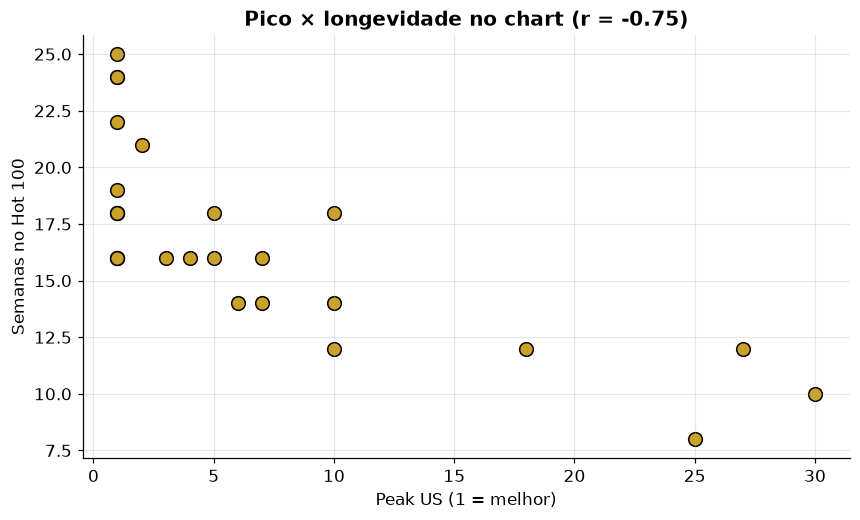

In [12]:
# Visual da pergunta (c): quanto melhor o pico (menor número), mais tempo no chart
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(sub["peak_us"], sub["weeks_chart_us"], s=80, color=MJ_GOLD, edgecolor="black")
ax.set_xlabel("Peak US (1 = melhor)"); ax.set_ylabel("Semanas no Hot 100")
ax.set_title(f"Pico × longevidade no chart (r = {r:.2f})", fontweight="bold")
fig.savefig(FIG / "02_peak_vs_weeks.png", bbox_inches="tight")
plt.show()

## ✅ Conclusões e próximos passos

**O que a descritiva mostrou**
- Vendas de álbum são **fortemente assimétricas**; *Thriller* é **outlier** (IQR e z-score) → use a **mediana** para o álbum típico.
- A maioria dos singles tem **longevidade alta** no chart; pico e semanas são **negativamente correlacionados** (descritivo).
- Singles **com clipe** apresentam médias diferentes de tempo em chart — mas isso ainda **não é um teste de significância**.

**Próximo notebook → `03` / `05` (Inferência)**
- Intervalo de confiança para a média de semanas em chart.
- **Teste de hipótese:** clipe afeta a longevidade no chart? (t-test / Mann-Whitney).
- **ANOVA:** desempenho por gênero; **Regressão:** prever semanas a partir do pico.